# NJL Hadron-Quark Mixed-Phase EOS Solver -- Multi-eta Sweep

Solves the Gibbs-construction hadron/quark/mixed-phase equation of state
(NJL quark sector, ZLA hadronic sector) for **any list of eta values you
choose**, saving each eta's result table to its own sheet in one Excel
file, then plots y_i vs n_B, f vs n_B, and P vs epsilon for all of them
together.

eta is the local-to-total electron ratio in the mixed phase (eta=1 is the
fully-local/Maxwell limit, eta=0 is the standard Gibbs/global-neutrality
limit).

## 1. Libraries

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import root, fsolve, least_squares
import os

## 2. Constants & parameters

In [43]:
HBAR = 197.3269804      # MeV fm  (= hbar*c)

# masses (MeV)
mN = 939.0
mu = 5.0                # up-quark mass   (NOTE: 'mu' is a MASS here, not a chem. pot.)
md_ = 7.0                # down-quark mass (renamed from 'md' to avoid clashing with the markdown helper)
ms = 150.0
me = 0.511

# Zhao-Lattimer (ZLA) nucleon parameters
nsat   = 0.16
a0, b0, gamma  = -96.64, 58.85, 1.40
a1, b1, gamma1 = -26.06,  7.34, 2.45

# vMIT quark parameters -- NO LONGER USED now that epsilon_quark/mu_quark below
# implement the NJL model instead. Left here only for reference / easy revert.
a_vmit = 0.20                # fm^2
B_vmit = (165.0) ** 4        # MeV^4

# ---- dataviz palette (categorical, fixed order -- see dataviz skill) ----
CAT = {
    "blue":    "#2a78d6",
    "orange":  "#eb6834",
    "aqua":    "#1baf7a",
    "yellow":  "#eda100",
    "magenta": "#e87ba4",
    "green":   "#008300",
    "violet":  "#4a3aa7",
    "red":     "#e34948",
}
GRID, INK, SECONDARY, SURFACE = "#e1e0d9", "#0b0b0b", "#52514e", "#fcfcfb"

def style_axes(ax):
    ax.set_facecolor(SURFACE)
    ax.grid(True, color=GRID, lw=0.8)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)

## 3. Helper functions

`kF_hadlep`/`kF_quark` turn a fraction y_i = n_i/n_B into a Fermi momentum
(g=2 for nucleons/leptons, g=6 for quarks -- color x spin). This part is
completely independent of which quark model (vMIT or NJL) computes the
energy from that Fermi momentum, so it is unchanged from the original
vMIT-based solver.

In [44]:
def safe_pow(x, p):
    return np.sign(x) * (np.abs(x) ** p)

def kF_hadlep(nb, y):
    return safe_pow(3.0 * np.pi**2 * HBAR**3 * nb * y, 1.0/3.0)

def kF_quark(nb, y):
    return safe_pow(np.pi**2 * HBAR**3 * nb * y, 1.0/3.0)

def calculate_fractions(nb, yn, yp, ys, ye, f):
    denom = 1.0 - np.clip(f, 0.0, 0.999999)
    yu  = (1.0 + ye - f*yn - 2.0*f*yp) / denom
    yd  = (2.0 - ye - 2.0*f*yn - f*yp - ys*denom) / denom
    yeN = yp
    yeQ = (ye - f*yp) / denom
    yeG = ye
    return yu, yd, yeN, yeQ, yeG

## 4. NJL quark model

Gap equations (eqs. 2-3), condensate (eq. 3), and B_eff (eqs. 9-11) from
Schertler, Leupold, Schaffner-Bielich (astro-ph/9901152). Vacuum masses and
B0 are solved once at import time as a validation check.

In [45]:
NJL_LAMBDA = 602.3                  # MeV, 3-momentum cutoff
NJL_G      = 1.835 / NJL_LAMBDA**2  # MeV^-2   (G*Lambda^2 = 1.835)
NJL_K      = 12.36 / NJL_LAMBDA**5  # MeV^-5   (K*Lambda^5 = 12.36)
NJL_MQ     = 5.5                    # MeV, current mass of u,d
NJL_MS     = 140.7                  # MeV, current mass of s


def _njl_term(p, m):
    E = np.sqrt(p**2 + m**2)
    return p*E*(2.0*p**2 + m**2) - m**4*np.log(np.abs(p + E)/m)

def _njl_F(p, m):
    E = np.sqrt(p**2 + m**2)
    return p*E - m**2*np.log(p + E)

def _njl_condensate(m_star, pF):
    if pF >= NJL_LAMBDA:
        return 0.0
    return -(3.0/np.pi**2) * m_star * 0.5 * (_njl_F(NJL_LAMBDA, m_star) - _njl_F(pF, m_star))

def _njl_gap_residuals(m_stars, pF):
    m_u, m_d, m_s = m_stars
    pFu, pFd, pFs = pF
    cu = _njl_condensate(m_u, pFu)
    cd = _njl_condensate(m_d, pFd)
    cs = _njl_condensate(m_s, pFs)
    eq_u = m_u - (NJL_MQ - 4*NJL_G*cu + 2*NJL_K*cd*cs)
    eq_d = m_d - (NJL_MQ - 4*NJL_G*cd + 2*NJL_K*cu*cs)
    eq_s = m_s - (NJL_MS - 4*NJL_G*cs + 2*NJL_K*cu*cd)
    return [eq_u, eq_d, eq_s]

_njl_mass_guess = [80.0, 65.0, 466.0]      # warm-start cache, updated after every solve

def _njl_solve_masses(pFu, pFd, pFs):
    global _njl_mass_guess
    pF = [pFu, pFd, pFs]
    guesses_to_try = [_njl_mass_guess, [367.6, 367.6, 549.5], [50.0, 50.0, 460.0], [NJL_MQ, NJL_MQ, NJL_MS]]

    best_sol, best_res = None, np.inf
    for g in guesses_to_try:
        sol = fsolve(_njl_gap_residuals, g, args=(pF,), xtol=1e-10)
        res = np.max(np.abs(_njl_gap_residuals(sol, pF)))
        if res < best_res:
            best_sol, best_res = sol, res
        if res < 1e-6 and np.all(np.array(sol) > -1.0):
            _njl_mass_guess = list(sol)
            return sol
    _njl_mass_guess = list(best_sol)
    return best_sol

def _njl_B_flavor(m_star, m_current, condensate_val):
    return (3.0/(8.0*np.pi**2)) * (_njl_term(NJL_LAMBDA, m_star) - _njl_term(NJL_LAMBDA, m_current)) \
           - 2*NJL_G*condensate_val**2

def _njl_B_total(m_star_u, m_star_d, m_star_s, cu, cd, cs):
    Bu = _njl_B_flavor(m_star_u, NJL_MQ, cu)
    Bd = _njl_B_flavor(m_star_d, NJL_MQ, cd)
    Bs = _njl_B_flavor(m_star_s, NJL_MS, cs)
    return Bu + Bd + Bs + 4*NJL_K*cu*cd*cs


_vac_masses = fsolve(_njl_gap_residuals, [367.0, 367.0, 549.0], args=([0.0, 0.0, 0.0],), xtol=1e-10)
_vac_cu = _njl_condensate(_vac_masses[0], 0.0)
_vac_cd = _njl_condensate(_vac_masses[1], 0.0)
_vac_cs = _njl_condensate(_vac_masses[2], 0.0)
NJL_B0 = _njl_B_total(_vac_masses[0], _vac_masses[1], _vac_masses[2], _vac_cu, _vac_cd, _vac_cs)
print(f"[NJL] vacuum masses: m*_u={_vac_masses[0]:.1f}  m*_d={_vac_masses[1]:.1f}  m*_s={_vac_masses[2]:.1f} MeV"
      f"  (paper: 367.7, 367.7, 549.5)")
print(f"[NJL] B0^(1/4) = {NJL_B0**0.25:.1f} MeV  (paper: 217.6 MeV)")

_njl_state_cache = {"key": None, "masses": None}

def _njl_masses_for(kFu, kFd, kFs):
    key = (round(float(kFu), 6), round(float(kFd), 6), round(float(kFs), 6))
    if _njl_state_cache["key"] == key:
        return _njl_state_cache["masses"]
    m_stars = _njl_solve_masses(kFu, kFd, kFs)
    _njl_state_cache["key"] = key
    _njl_state_cache["masses"] = m_stars
    return m_stars

[NJL] vacuum masses: m*_u=367.6  m*_d=367.6  m*_s=549.5 MeV  (paper: 367.7, 367.7, 549.5)
[NJL] B0^(1/4) = 217.6 MeV  (paper: 217.6 MeV)


## 5. Energy densities, chemical potentials, pressures

In [46]:
def epsilon_hadronic(nb, yn, yp, kFn, kFp):
    En, Ep = np.sqrt(kFn**2 + mN**2), np.sqrt(kFp**2 + mN**2)
    term_n = kFn*En*(2.0*kFn**2 + mN**2) - mN**4*np.log(np.abs(kFn + En)/mN)
    term_p = kFp*Ep*(2.0*kFp**2 + mN**2) - mN**4*np.log(np.abs(kFp + Ep)/mN)
    kinetic = (term_n + term_p) / (8.0*np.pi**2*HBAR**3)

    rho = nb * (yn + yp)
    int1 = 4.0*nb**2*yn*yp*(a0/nsat + (b0/nsat**gamma)*safe_pow(rho, gamma-1))
    int2 = nb**2*(yn-yp)**2*(a1/nsat + (b1/nsat**gamma1)*safe_pow(rho, gamma1-1))
    return kinetic + int1 + int2

def epsilon_quark(nb, yu, yd, ys, kFu, kFd, kFs):
    m_star_u, m_star_d, m_star_s = _njl_masses_for(kFu, kFd, kFs)
    cu = _njl_condensate(m_star_u, kFu)
    cd = _njl_condensate(m_star_d, kFd)
    cs = _njl_condensate(m_star_s, kFs)

    eps_kin = (3.0*_njl_term(kFu, m_star_u)
               + 3.0*_njl_term(kFd, m_star_d)
               + 3.0*_njl_term(kFs, m_star_s)) / (8.0*np.pi**2)
    B_now = _njl_B_total(m_star_u, m_star_d, m_star_s, cu, cd, cs)
    B_eff = NJL_B0 - B_now

    eps_NJL_natural = eps_kin + B_eff          # MeV^4
    return eps_NJL_natural / (HBAR**3)         # MeV/fm^3

def epsilon_lepton(kF, mass):
    E = np.sqrt(kF**2 + mass**2)
    term = kF*E*(2.0*kF**2 + mass**2) - mass**4*np.log(np.abs(kF + E)/mass)
    return term / (8.0*np.pi**2*HBAR**3)


def mu_hadronic(nb, yn, yp, kFn, kFp):
    rho = yn + yp
    common0 = a0*(nb/nsat) + b0*(nb/nsat)**gamma  * rho**(gamma-1)
    common1 = a1*(nb/nsat) + b1*(nb/nsat)**gamma1 * rho**(gamma1-1)
    d0 = b0*(nb/nsat)**gamma *(gamma -1)*rho**(gamma -2)
    d1 = b1*(nb/nsat)**gamma1*(gamma1-1)*rho**(gamma1-2)
    mu_n = (np.sqrt(kFn**2 + mN**2) + 4*yp*common0 + 4*yn*yp*d0
            + 2*(yn-yp)*common1 + (yn-yp)**2*d1)
    mu_p = (np.sqrt(kFp**2 + mN**2) + 4*yn*common0 + 4*yn*yp*d0
            - 2*(yn-yp)*common1 + (yn-yp)**2*d1)
    return mu_n, mu_p

def mu_quark(nb, yu, yd, ys, kFu, kFd, kFs):
    m_star_u, m_star_d, m_star_s = _njl_masses_for(kFu, kFd, kFs)
    mu_u = np.sqrt(kFu**2 + m_star_u**2)
    mu_d = np.sqrt(kFd**2 + m_star_d**2)
    mu_s = np.sqrt(kFs**2 + m_star_s**2)
    return mu_u, mu_d, mu_s

def mu_lepton(kF, mass):
    return np.sqrt(kF**2 + mass**2)


def pressure_hadronic(nb, yn, yp, mu_n, mu_p, epsN):
    return nb*(yn*mu_n + yp*mu_p) - epsN

def pressure_quark(nb, yu, yd, ys, mu_u, mu_d, mu_s, epsQ):
    return nb*(yu*mu_u + yd*mu_d + ys*mu_s) - epsQ

def pressure_lepton(nb, ye, mu_e, eps_e):
    return nb*ye*mu_e - eps_e

## 6. Full mixed-phase state and record builder

In [47]:
def calculate_state(nb, yn, yp, ys, ye, f):
    yu, yd, yeN, yeQ, yeG = calculate_fractions(nb, yn, yp, ys, ye, f)

    yn_s, yp_s = np.maximum(yn, 1e-12), np.maximum(yp, 1e-12)
    yu_s, yd_s, ys_s = np.maximum(yu, 1e-12), np.maximum(yd, 1e-12), np.maximum(ys, 1e-12)
    yeN_s, yeQ_s, yeG_s = (np.maximum(yeN, 1e-12),
                           np.maximum(yeQ, 1e-12), np.maximum(yeG, 1e-12))

    kFn, kFp = kF_hadlep(nb, yn_s), kF_hadlep(nb, yp_s)
    kFu, kFd, kFs = kF_quark(nb, yu_s), kF_quark(nb, yd_s), kF_quark(nb, ys_s)
    kFeN, kFeQ, kFeG = (kF_hadlep(nb, yeN_s),
                        kF_hadlep(nb, yeQ_s), kF_hadlep(nb, yeG_s))

    epsN = epsilon_hadronic(nb, yn_s, yp_s, kFn, kFp)
    epsQ = epsilon_quark(nb, yu_s, yd_s, ys_s, kFu, kFd, kFs)
    eps_eN, eps_eQ, eps_eG = (epsilon_lepton(kFeN, me),
                              epsilon_lepton(kFeQ, me), epsilon_lepton(kFeG, me))

    mu_n, mu_p = mu_hadronic(nb, yn_s, yp_s, kFn, kFp)
    mu_u, mu_d, mu_s = mu_quark(nb, yu_s, yd_s, ys_s, kFu, kFd, kFs)
    mu_eN, mu_eQ, mu_eG = (mu_lepton(kFeN, me),
                           mu_lepton(kFeQ, me), mu_lepton(kFeG, me))

    PN = pressure_hadronic(nb, yn_s, yp_s, mu_n, mu_p, epsN)
    PQ = pressure_quark(nb, yu_s, yd_s, ys_s, mu_u, mu_d, mu_s, epsQ)
    PeN = pressure_lepton(nb, yeN_s, mu_eN, eps_eN)
    PeQ = pressure_lepton(nb, yeQ_s, mu_eQ, eps_eQ)
    PeG = pressure_lepton(nb, yeG_s, mu_eG, eps_eG)

    return dict(yu=yu, yd=yd, ys=ys, yeN=yeN, yeQ=yeQ, yeG=yeG,
                kFn=kFn, kFp=kFp, kFu=kFu, kFd=kFd, kFs=kFs,
                kFeN=kFeN, kFeQ=kFeQ, kFeG=kFeG,
                mu_n=mu_n, mu_p=mu_p, mu_u=mu_u, mu_d=mu_d, mu_s=mu_s,
                mu_eN=mu_eN, mu_eQ=mu_eQ, mu_eG=mu_eG,
                epsilonN=epsN, epsilonQ=epsQ,
                epsilon_eN=eps_eN, epsilon_eQ=eps_eQ, epsilon_eG=eps_eG,
                PN=PN, PQ=PQ, PeN=PeN, PeQ=PeQ, PeG=PeG)


COLUMNS = [
    "nB", "phase", "f",
    "yn", "yp", "yu", "yd", "ys", "ye", "yeN", "yeQ", "yeG",
    "kFn", "kFp", "kFu", "kFd", "kFs", "kFeN", "kFeQ", "kFeG",
    "mu_n", "mu_p", "mu_u", "mu_d", "mu_s", "mu_eN", "mu_eQ", "mu_eG",
    "epsilonN", "epsilonQ", "epsilon_eN", "epsilon_eQ", "epsilon_eG", "eps_total",
    "PN", "PQ", "PeN", "PeQ", "PeG", "P_total",
]

def blank_record():
    r = {c: 0.0 for c in COLUMNS}
    r["phase"] = ""
    return r

## 7. Pure-phase branch solvers (hadron, quark)

In [48]:
def solve_hadron(nb, yp_guess):
    def eq(v):
        yp = v[0]
        if yp <= 1e-9 or yp >= 1.0:
            return [1e6]
        yn, ye = 1.0 - yp, yp
        kFn, kFp = kF_hadlep(nb, yn), kF_hadlep(nb, yp)
        kFe = kF_hadlep(nb, ye)
        mu_n, mu_p = mu_hadronic(nb, yn, yp, kFn, kFp)
        mu_e = mu_lepton(kFe, me)
        return [mu_n - mu_p - mu_e]

    sol = root(eq, [yp_guess], method='hybr', tol=1e-10)
    if not sol.success or not (0.0 < sol.x[0] < 1.0):
        return None
    yp = sol.x[0]; yn, ye = 1.0 - yp, yp
    kFn, kFp, kFe = kF_hadlep(nb, yn), kF_hadlep(nb, yp), kF_hadlep(nb, ye)
    mu_n, mu_p = mu_hadronic(nb, yn, yp, kFn, kFp)
    mu_e = mu_lepton(kFe, me)
    epsN = epsilon_hadronic(nb, yn, yp, kFn, kFp)
    eps_e = epsilon_lepton(kFe, me)
    PN = pressure_hadronic(nb, yn, yp, mu_n, mu_p, epsN)
    Pe = pressure_lepton(nb, ye, mu_e, eps_e)

    r = blank_record()
    r.update(phase='hadron', f=1.0, yn=yn, yp=yp, ye=ye, yeN=ye,
             kFn=kFn, kFp=kFp, kFeN=kFe,
             mu_n=mu_n, mu_p=mu_p, mu_eN=mu_e,
             epsilonN=epsN, epsilon_eN=eps_e, eps_total=epsN + eps_e,
             PN=PN, PeN=Pe, P_total=PN + Pe)
    r["eps"] = r["eps_total"]; r["x"] = [yp]
    return r


def solve_quark(nb, guess):
    def eq(v):
        yu, yd, ys, ye = v
        kFu, kFd, kFs = kF_quark(nb, yu), kF_quark(nb, yd), kF_quark(nb, ys)
        kFe = kF_hadlep(nb, max(ye, 1e-12))
        mu_u, mu_d, mu_s = mu_quark(nb, yu, yd, ys, kFu, kFd, kFs)
        mu_e = mu_lepton(kFe, me)
        return [yu + yd + ys - 3.0,
                (2.0*yu - yd - ys)/3.0 - ye,
                mu_d - mu_u - mu_e,
                mu_s - mu_d]

    sol = root(eq, guess, method='hybr', tol=1e-10)
    if not sol.success:
        sol = root(eq, guess, method='lm', tol=1e-10)
        if not sol.success:
            return None
    yu, yd, ys, ye = sol.x
    if min(yu, yd, ys) <= 0 or ye < 0:
        return None
    kFu, kFd, kFs = kF_quark(nb, yu), kF_quark(nb, yd), kF_quark(nb, ys)
    kFe = kF_hadlep(nb, max(ye, 1e-12))
    mu_u, mu_d, mu_s = mu_quark(nb, yu, yd, ys, kFu, kFd, kFs)
    mu_e = mu_lepton(kFe, me)
    epsQ = epsilon_quark(nb, yu, yd, ys, kFu, kFd, kFs)
    eps_e = epsilon_lepton(kFe, me)
    PQ = pressure_quark(nb, yu, yd, ys, mu_u, mu_d, mu_s, epsQ)
    Pe = pressure_lepton(nb, ye, mu_e, eps_e)

    r = blank_record()
    r.update(phase='quark', f=0.0, yu=yu, yd=yd, ys=ys, ye=ye, yeQ=ye,
             kFu=kFu, kFd=kFd, kFs=kFs, kFeQ=kFe,
             mu_u=mu_u, mu_d=mu_d, mu_s=mu_s, mu_eQ=mu_e,
             epsilonQ=epsQ, epsilon_eQ=eps_e, eps_total=epsQ + eps_e,
             PQ=PQ, PeQ=Pe, P_total=PQ + Pe)
    r["eps"] = r["eps_total"]; r["x"] = list(sol.x)
    return r

## 8. Mixed-phase branch (R1-R5) and the robust boundary-tracking solver

`solve_mixed` tries a plain solve first and only pays for the expensive
bounded least-squares fallback when asked to. `solve_mixed_continued`
bisects the density step to track the mixed branch all the way to wherever
it genuinely ends (f -> 0 or f -> 1), instead of dropping a boundary point
and creating a false pressure spike -- this is the fix worked out earlier
for the eta=0.6 case.

In [49]:
def mixed_residuals(x, nb, eta):
    yn, yp, ys, ye, f = x

    pen = 0.0
    for val in (yn, yp, ys, ye):
        if val < 0.0:
            pen += 1e6 * (-val)
    if f < 0.0:
        pen += 1e6 * (-f)
    if f > 1.0:
        pen += 1e6 * (f - 1.0)

    try:
        s = calculate_state(nb, yn, yp, ys, ye, f)
        R1 = s['mu_n'] - (s['mu_u'] + 2.0*s['mu_d'])
        R2 = s['mu_p'] - (2.0*s['mu_u'] + s['mu_d'] - eta*(s['mu_eN'] - s['mu_eQ']))
        R3 = s['mu_d'] - (s['mu_u'] + eta*s['mu_eQ'] + (1.0 - eta)*s['mu_eG'])
        R4 = s['mu_d'] - s['mu_s']
        R5 = (s['PN'] + eta*s['PeN']) - (s['PQ'] + eta*s['PeQ'])
        return [R1 + pen, R2 + pen, R3 + pen, R4 + pen, R5 + pen]
    except Exception:
        return [1e10]*5


DEBUG_SOLVER = False

def _mixed_candidate_from_x(x, nb, eta):
    yn, yp, ys, ye, f = x
    if not (0.0 < f < 1.0):
        return None
    res = np.max(np.abs(mixed_residuals(x, nb, eta)))
    if res > 1e-3:
        return None
    s = calculate_state(nb, yn, yp, ys, ye, f)
    yu, yd = s['yu'], s['yd']
    if min(yn, yp, ys, yu, yd) < -1e-6 or max(yu, yd, ys) > 3.2:
        return None
    eps = (f*s['epsilonN'] + (1-f)*s['epsilonQ']
           + f*eta*s['epsilon_eN'] + (1-f)*eta*s['epsilon_eQ']
           + (1-eta)*s['epsilon_eG'])
    P = (f*s['PN'] + (1-f)*s['PQ']
         + f*eta*s['PeN'] + (1-f)*eta*s['PeQ'] + (1-eta)*s['PeG'])
    r = blank_record()
    r.update(phase='mixed', f=f, yn=yn, yp=yp, ys=ys, ye=ye,
             yu=yu, yd=yd, yeN=s['yeN'], yeQ=s['yeQ'], yeG=s['yeG'],
             kFn=s['kFn'], kFp=s['kFp'], kFu=s['kFu'], kFd=s['kFd'], kFs=s['kFs'],
             kFeN=s['kFeN'], kFeQ=s['kFeQ'], kFeG=s['kFeG'],
             mu_n=s['mu_n'], mu_p=s['mu_p'], mu_u=s['mu_u'], mu_d=s['mu_d'], mu_s=s['mu_s'],
             mu_eN=s['mu_eN'], mu_eQ=s['mu_eQ'], mu_eG=s['mu_eG'],
             epsilonN=s['epsilonN'], epsilonQ=s['epsilonQ'],
             epsilon_eN=s['epsilon_eN'], epsilon_eQ=s['epsilon_eQ'],
             epsilon_eG=s['epsilon_eG'], eps_total=eps,
             PN=s['PN'], PQ=s['PQ'], PeN=s['PeN'], PeQ=s['PeQ'], PeG=s['PeG'],
             P_total=P)
    r["eps"] = eps; r["x"] = list(x)
    return r


_MIX_BOUNDS = ([0.0, 0.0, 0.0, 0.0, 0.0], [2.0, 2.0, 4.0, 2.0, 1.0])


def solve_mixed(nb, eta, guesses, use_bounded_fallback=False):
    for gi, g in enumerate(guesses):
        for method in ('hybr', 'lm'):
            sol = root(mixed_residuals, g, args=(nb, eta), method=method, tol=1e-9)
            if DEBUG_SOLVER:
                res_dbg = np.max(np.abs(mixed_residuals(sol.x, nb, eta)))
                print(f"        try guess#{gi} [{method}]  success={sol.success}"
                      f"  root=[yn={sol.x[0]:.3f} yp={sol.x[1]:.3f} ys={sol.x[2]:.3f}"
                      f" ye={sol.x[3]:.3f} f={sol.x[4]:.3f}]  maxres={res_dbg:.2e}")
            if not sol.success:
                continue
            r = _mixed_candidate_from_x(sol.x, nb, eta)
            if r is not None:
                return r

        if not use_bounded_fallback:
            continue

        g_clipped = np.clip(g, _MIX_BOUNDS[0], _MIX_BOUNDS[1])
        try:
            lsq = least_squares(mixed_residuals, g_clipped, args=(nb, eta),
                                 bounds=_MIX_BOUNDS, xtol=1e-14, ftol=1e-14,
                                 gtol=1e-14, max_nfev=1500)
        except Exception:
            lsq = None
        if lsq is not None:
            if DEBUG_SOLVER:
                res_dbg = np.max(np.abs(mixed_residuals(lsq.x, nb, eta)))
                print(f"        try guess#{gi} [lsq-bounded]  "
                      f"root=[yn={lsq.x[0]:.3f} yp={lsq.x[1]:.3f} ys={lsq.x[2]:.3f}"
                      f" ye={lsq.x[3]:.3f} f={lsq.x[4]:.3f}]  maxres={res_dbg:.2e}")
            r = _mixed_candidate_from_x(lsq.x, nb, eta)
            if r is not None:
                return r
    return None


_MIX_BOUNDARY_EPS = 1e-4


def solve_mixed_continued(nb, nb_prev, eta, g_prev, extra_guesses, depth=0, max_depth=6):
    if g_prev is not None:
        f_prev = g_prev[4]
        if f_prev < _MIX_BOUNDARY_EPS or f_prev > 1.0 - _MIX_BOUNDARY_EPS:
            return None, g_prev, nb_prev

    guesses = ([g_prev] if g_prev is not None else []) + extra_guesses
    m = solve_mixed(nb, eta, guesses, use_bounded_fallback=(depth > 0))
    if m is not None:
        return m, m['x'], nb
    if depth >= max_depth or g_prev is None:
        return None, g_prev, nb_prev
    nb_mid = 0.5*(nb_prev + nb)
    m_mid, g_mid, nb_mid_reached = solve_mixed_continued(
        nb_mid, nb_prev, eta, g_prev, extra_guesses, depth+1, max_depth)
    if g_mid is None:
        return None, g_prev, nb_prev
    return solve_mixed_continued(nb, nb_mid_reached, eta, g_mid, extra_guesses,
                                  depth+1, max_depth)

## 9. Main solve, wrapped as a function of eta

This is the same main loop as before, just wrapped in a function so it can
be called once per eta value in a clean loop. All the warm-start state
(`g_had`, `g_qrk`, `g_mix_prev`, ...) is local to each call, so different
eta runs never interfere with each other. Includes the "give up after 2
consecutive mixed-phase failures" fix, which matters most at eta close to
1 (the mixed phase can end abruptly there -- see the eta=1.0 case worked
out earlier).

In [50]:
def solve_eos_for_eta(eta, nb_values, verbose=False):
    g_had = 0.9
    g_qrk = [.1, .1, 0.1, 0.02]
    g_mix_prev = None
    nb_mix_prev = None
    mix_consecutive_fail = 0
    MIX_GIVEUP_AFTER = 2

    cold_guesses = [
        [0.90, 0.06, 0.05, 0.05, 0.80],
        [0.70, 0.10, 0.30, 0.03, 0.50],
        [0.50, 0.12, 0.60, 0.01, 0.30],
        [0.30, 0.10, 0.90, 0.00, 0.15],
    ]

    results = []
    for i, nb in enumerate(nb_values):
        candidates = []

        h = solve_hadron(nb, g_had)
        if h:
            candidates.append(h); g_had = h['yp']

        q = solve_quark(nb, g_qrk)
        if q:
            candidates.append(q); g_qrk = q['x']

        if mix_consecutive_fail >= MIX_GIVEUP_AFTER:
            m = None
        elif g_mix_prev is not None and nb_mix_prev is not None:
            m, g_from_continuation, nb_reached = solve_mixed_continued(
                nb, nb_mix_prev, eta, g_mix_prev, cold_guesses)
            if g_from_continuation is not None:
                g_mix_prev = g_from_continuation
                nb_mix_prev = nb_reached
        else:
            m = solve_mixed(nb, eta, cold_guesses)

        if m:
            candidates.append(m); g_mix_prev = m['x']; nb_mix_prev = nb
            mix_consecutive_fail = 0
        elif g_mix_prev is not None:
            mix_consecutive_fail += 1

        if not candidates:
            if verbose:
                print(f"  eta={eta:.2f}  {i+1:3d}/{len(nb_values)}  nB={nb:.3f}  NO SOLUTION")
            continue

        best = min(candidates, key=lambda c: c['eps'])
        best["nB"] = nb
        results.append({c: best[c] for c in COLUMNS})

        if verbose:
            print(f"  eta={eta:.2f}  {i+1:3d}/{len(nb_values)}  nB={nb:.3f}  -> {best['phase']:6s}"
                  f"  f={best['f']:.3f}  eps={best['eps_total']:8.2f}  P={best['P_total']:8.2f}")

    return pd.DataFrame(results, columns=COLUMNS)

## 10. Input -- choose the eta values and the density grid

Edit `ETA_VALUES` to whatever list you want (any number of values, in any
order) -- the solver below loops over exactly this list.

In [51]:
ETA_VALUES = [0.0, 0.1,0.2,0.3, 0.4,0.5,0.6,0.7,0.8, 0.9, 1.0]     # <-- edit this list freely
nb_values  = np.arange(0.05, 2.00, 0.01)   # baryon density grid, fm^-3

OUTPUT_XLSX = "final_eos_solved_output_NJL.xlsx"

print(f"Will solve for {len(ETA_VALUES)} eta value(s): {ETA_VALUES}")
print(f"Density grid: {nb_values[0]:.2f} to {nb_values[-1]:.2f} fm^-3, {len(nb_values)} points")

Will solve for 11 eta value(s): [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
Density grid: 0.05 to 1.99 fm^-3, 195 points


## 11. Solve for every eta value, save each to its own sheet

Each eta's result table is kept in memory (`results_by_eta`) for plotting
right away, and also written to its own sheet (named `eta_<value>_NJL`) in
one combined Excel file.

In [ ]:
results_by_eta = {}

for eta in ETA_VALUES:
    print(f"\n=== Solving eta = {eta:.2f} ===")
    df_eta = solve_eos_for_eta(eta, nb_values, verbose=False)
    results_by_eta[eta] = df_eta
    print(f"  -> {len(df_eta)} points converged "
          f"(phases: {df_eta['phase'].value_counts().to_dict()})")

sheet_names = {eta: f"eta_{eta:.2f}_NJL" for eta in ETA_VALUES}

with pd.ExcelWriter(OUTPUT_XLSX, engine="openpyxl") as writer:
    for eta, df_eta in results_by_eta.items():
        df_eta.to_excel(writer, sheet_name=sheet_names[eta], index=False)

print(f"\nSaved {len(results_by_eta)} sheet(s) to {OUTPUT_XLSX}: {list(sheet_names.values())}")


=== Solving eta = 0.00 ===


/tmp/ipykernel_478587/3816044024.py:41: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  sol = fsolve(_njl_gap_residuals, g, args=(pF,), xtol=1e-10)
/tmp/ipykernel_478587/3816044024.py:41: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last five Jacobian evaluations.
  sol = fsolve(_njl_gap_residuals, g, args=(pF,), xtol=1e-10)


  -> 195 points converged (phases: {'mixed': 111, 'hadron': 45, 'quark': 39})

=== Solving eta = 0.10 ===
  -> 195 points converged (phases: {'mixed': 100, 'quark': 48, 'hadron': 47})

=== Solving eta = 0.20 ===
  -> 195 points converged (phases: {'mixed': 90, 'quark': 56, 'hadron': 49})

=== Solving eta = 0.30 ===
  -> 195 points converged (phases: {'mixed': 81, 'quark': 63, 'hadron': 51})

=== Solving eta = 0.40 ===
  -> 195 points converged (phases: {'mixed': 72, 'quark': 70, 'hadron': 53})

=== Solving eta = 0.50 ===
  -> 195 points converged (phases: {'quark': 76, 'mixed': 65, 'hadron': 54})

=== Solving eta = 0.60 ===
  -> 195 points converged (phases: {'quark': 81, 'mixed': 58, 'hadron': 56})

=== Solving eta = 0.70 ===
  -> 195 points converged (phases: {'quark': 85, 'hadron': 57, 'mixed': 53})

=== Solving eta = 0.80 ===


## 12. Plot: f (hadron volume fraction) vs n_B, all eta together

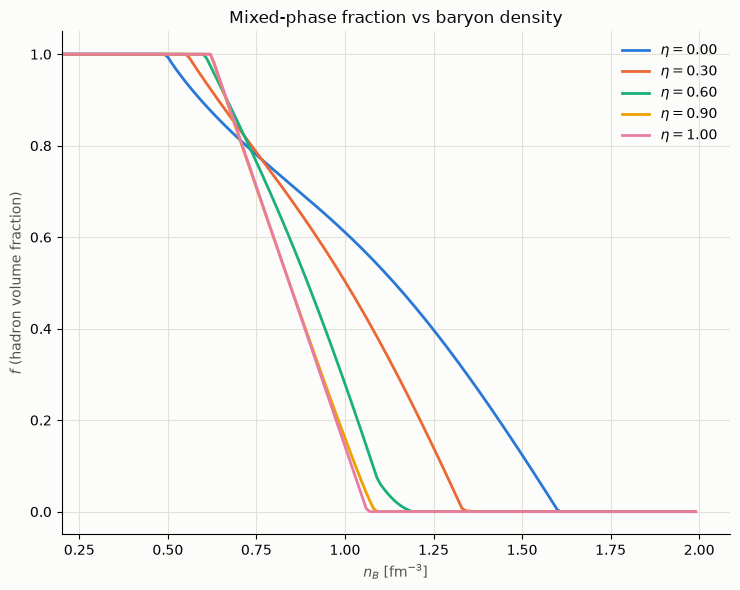

In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 6))
fig.patch.set_facecolor(SURFACE)
style_axes(ax)

palette_order = list(CAT.values())
for i, eta in enumerate(ETA_VALUES):
    df_eta = results_by_eta[eta]
    color = palette_order[i % len(palette_order)]
    ax.plot(df_eta["nB"], df_eta["f"], color=color, lw=2, label=rf"$\eta = {eta:.2f}$")
ax.set_xlim(0.1,None)
ax.set_xlabel(r"$n_B$ [fm$^{-3}$]", color=SECONDARY)
ax.set_ylabel(r"$f$ (hadron volume fraction)", color=SECONDARY)
ax.set_title("Mixed-phase fraction vs baryon density", color=INK)
ax.legend(frameon=False, fontsize=10, loc="upper right")
plt.tight_layout()
plt.savefig("f_vs_nb_all_eta.png", dpi=150, facecolor=SURFACE)
plt.show()

## 14. Plot: P vs epsilon (the EOS), all eta together

This is the plot that originally showed the eta=0.6 spike -- now smooth
for every eta thanks to the boundary-tracking fix in `solve_mixed_continued`.

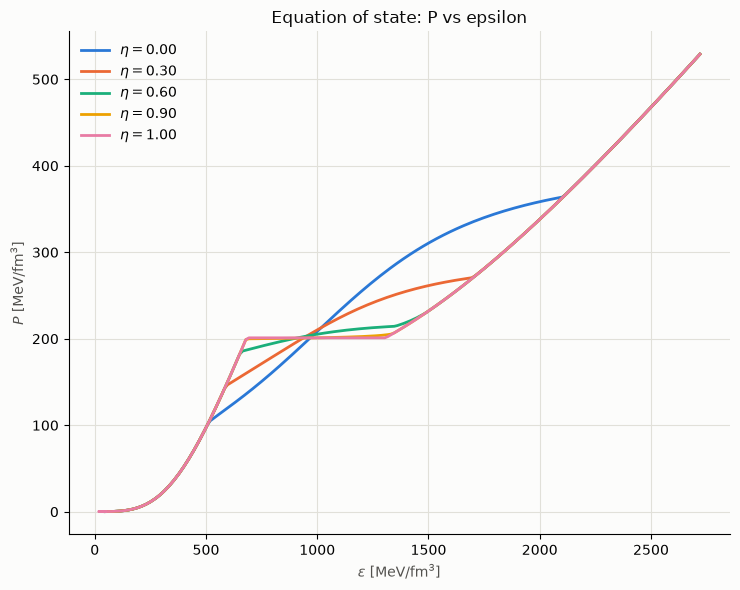

In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 6))
fig.patch.set_facecolor(SURFACE)
style_axes(ax)

for i, eta in enumerate(ETA_VALUES):
    df_eta = results_by_eta[eta]
    color = palette_order[i % len(palette_order)]
    ax.plot(df_eta["eps_total"], df_eta["P_total"], color=color, lw=2, label=rf"$\eta = {eta:.2f}$")

ax.set_xlabel(r"$\epsilon$ [MeV/fm$^3$]", color=SECONDARY)
ax.set_ylabel(r"$P$ [MeV/fm$^3$]", color=SECONDARY)
ax.set_title("Equation of state: P vs epsilon", color=INK)
ax.legend(frameon=False, fontsize=10, loc="upper left")
plt.tight_layout()
plt.savefig("P_vs_eps_all_eta.png", dpi=150, facecolor=SURFACE)
plt.show()

## 15. Mass-Radius curve (TOV equations) -- for every eta

Solves the Tolman-Oppenheimer-Volkoff (TOV) equations using each eta's
`P_total` / `eps_total` columns as the EOS input, sweeping over a range of
central pressures to build one M-R curve per eta. The TOV integration
logic itself is unchanged from the original single-eta script -- it's
just wrapped in a function so it can be run once per eta, and all curves
are collected together for one combined plot at the end.

In [ ]:
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

# constants (CGS)
G_grav = 6.67430e-8
c_light = 2.99792458e10
solar_mass = 1.989e33

In [ ]:
def find_ns_radius(pressure, radius_array):
    """Find the stellar surface: first point where pressure drops to/below 0."""
    mask = (pressure <= 0).astype(int)
    index = np.argmax(mask)
    if index == 0:
        return radius_array[-1], len(radius_array) - 1
    return radius_array[index], index


def solve_mr_curve(p_min, p_max, pressure_to_energy_density):
    """Integrate the TOV equations over a range of central pressures for
    ONE eos (one eta), returning the M-R curve data. Logic is identical to
    the original single-eta script -- only wrapped in a function so it can
    be called once per eta."""

    def tov_equations_dimensional(r, state):
        P, m = state

        if r < 1e-5:
            r = 1e-5
        if m < 1e-6:
            m = 1e-6

        if P <= 0:
            return [0.0, 0.0]

        try:
            epsilon_val = pressure_to_energy_density(P)
        except ValueError:
            return [0.0, 0.0]

        dPdr = - (G_grav * (epsilon_val + P / c_light**2) *
                  (m + 4 * np.pi * r**3 * P / c_light**2)) / \
                (r * (r - 2 * G_grav * m / c_light**2))

        dmdr = 4 * np.pi * r**2 * epsilon_val

        return [dPdr, dmdr]

    def stop_integration_out_of_range(r, state):
        P, _ = state
        if P < p_min or P > p_max:
            return 0
        return 1
    stop_integration_out_of_range.terminal = True
    stop_integration_out_of_range.direction = -1

    r_array = np.linspace(1e-6, 20e5, 5000)
    P_central_values = np.logspace(34.5, 37.5, 70)

    M_list, R_list, central_density_list, P_list = [], [], [], []

    for P_central in P_central_values:
        try:
            central_density = pressure_to_energy_density(P_central)
        except ValueError:
            continue

        initial_conditions = [P_central, 0.0]

        sol = solve_ivp(
            tov_equations_dimensional,
            [r_array[0], r_array[-1]],
            initial_conditions,
            method='RK45',
            events=stop_integration_out_of_range,
            atol=1e-6,
            rtol=1e-6
        )

        if not sol.success:
            continue

        Pressure, Mass = sol.y
        radius_solver = sol.t

        radius_ns, index_ns = find_ns_radius(Pressure, radius_solver)

        final_radius = radius_ns / 1e5        # km
        final_mass = Mass[index_ns] / solar_mass

        R_list.append(final_radius)
        M_list.append(final_mass)
        central_density_list.append(central_density)
        P_list.append(P_central)

    return P_list, R_list, M_list, central_density_list

### Run the M-R solver for every eta and save to Excel

Each eta's `P_total`/`eps_total` columns (already computed above, in
`results_by_eta`) are converted to CGS units and turned into an
interpolant, then fed through `solve_mr_curve`. Every eta's M-R table is
kept in memory (`mr_results_by_eta`) and also written to its own sheet in
one combined Excel file.

In [ ]:
mr_results_by_eta = {}

for eta in ETA_VALUES:
    print(f"\n=== Solving M-R curve for eta = {eta:.2f} ===")
    df_eta = results_by_eta[eta]

    pressure = df_eta["P_total"].values
    epsilo = df_eta["eps_total"].values

    # Convert to CGS
    epsilon_cgs = epsilo * 1.78266192e12        # g/cm^3
    p_cgs = pressure * 1.60218e33               # dyn/cm^2

    pressure_to_energy_density = interp1d(p_cgs, epsilon_cgs, kind="linear", bounds_error=True)

    P_list, R_list, M_list, central_density_list = solve_mr_curve(
        p_cgs.min(), p_cgs.max(), pressure_to_energy_density
    )

    central_density_MeVfm3 = np.array(central_density_list) / 1.78266192e12

    mr_df = pd.DataFrame({
        "P_central (dyn/cm^2)": P_list,
        "Radius (km)": R_list,
        "Mass (M_sun)": M_list,
        "Central Density (g/cm^3)": central_density_list,
        "Central Density (MeV/fm^3)": central_density_MeVfm3,
    })

    mr_results_by_eta[eta] = mr_df
    print(f"  -> {len(mr_df)} central pressures converged, "
          f"M_max = {mr_df['Mass (M_sun)'].max():.3f} Msun "
          f"at R = {mr_df.loc[mr_df['Mass (M_sun)'].idxmax(), 'Radius (km)']:.2f} km")

MR_OUTPUT_XLSX = "Final_MR_curve_NJL.xlsx"
mr_sheet_names = {eta: f"eta_{eta:.2f}" for eta in ETA_VALUES}

with pd.ExcelWriter(MR_OUTPUT_XLSX, engine="openpyxl") as writer:
    for eta, mr_df in mr_results_by_eta.items():
        mr_df.to_excel(writer, sheet_name=mr_sheet_names[eta], index=False)

print(f"\nSaved {len(mr_results_by_eta)} sheet(s) to {MR_OUTPUT_XLSX}: {list(mr_sheet_names.values())}")


=== Solving M-R curve for eta = 0.00 ===
  -> 33 central pressures converged, M_max = 1.919 Msun at R = 11.49 km

=== Solving M-R curve for eta = 0.30 ===
  -> 33 central pressures converged, M_max = 2.021 Msun at R = 11.58 km

=== Solving M-R curve for eta = 0.60 ===
  -> 33 central pressures converged, M_max = 2.075 Msun at R = 11.66 km

=== Solving M-R curve for eta = 0.90 ===
  -> 33 central pressures converged, M_max = 2.083 Msun at R = 11.70 km

=== Solving M-R curve for eta = 1.00 ===
  -> 33 central pressures converged, M_max = 2.083 Msun at R = 11.72 km

Saved 5 sheet(s) to Final_MR_curve_NJL.xlsx: ['eta_0.00', 'eta_0.30', 'eta_0.60', 'eta_0.90', 'eta_1.00']


## 16. Plot: Mass-Radius curves, all eta together

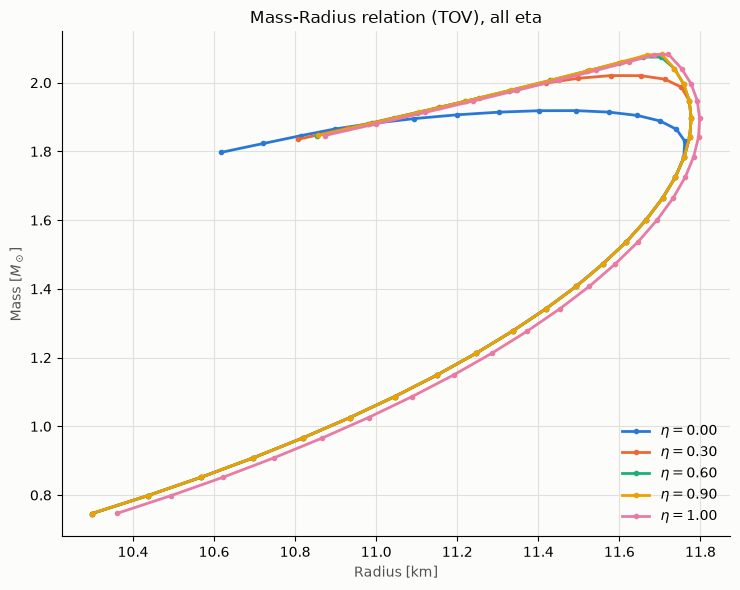

In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 6))
fig.patch.set_facecolor(SURFACE)
style_axes(ax)

for i, eta in enumerate(ETA_VALUES):
    mr_df = mr_results_by_eta[eta]
    color = palette_order[i % len(palette_order)]
    ax.plot(mr_df["Radius (km)"], mr_df["Mass (M_sun)"], color=color, lw=2,
            marker='o', markersize=3, label=rf"$\eta = {eta:.2f}$")

ax.set_xlabel("Radius [km]", color=SECONDARY)
ax.set_ylabel(r"Mass [$M_\odot$]", color=SECONDARY)
ax.set_title("Mass-Radius relation (TOV), all eta", color=INK)
ax.legend(frameon=False, fontsize=10, loc="lower right")
plt.tight_layout()
plt.savefig("MR_curve_all_eta.png", dpi=150, facecolor=SURFACE)
plt.show()